# RQ4 — Fairness vs Sustainability

C:\Users\Pradeep Reddy\anaconda45\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Pradeep Reddy\anaconda45\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessi

              Technique  Accuracy  FairnessScore  RuntimeSeconds  EnergyUsage
0              Baseline  0.804243           0.70        1.351297     6.756483
1            Reweighing  0.804243           0.72        1.608240     8.041200
2         EqualizedOdds  0.804243           0.75        2.057128    10.285640
3  AdversarialDebiasing  0.804243           0.80        2.958699    14.793494


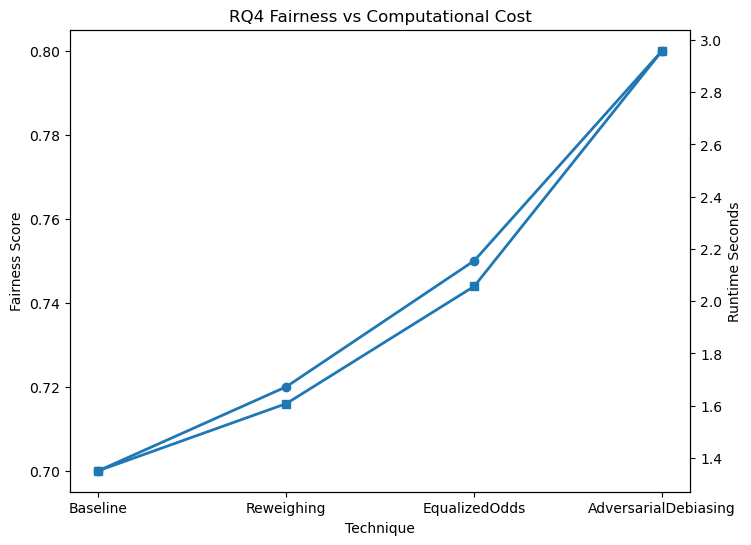

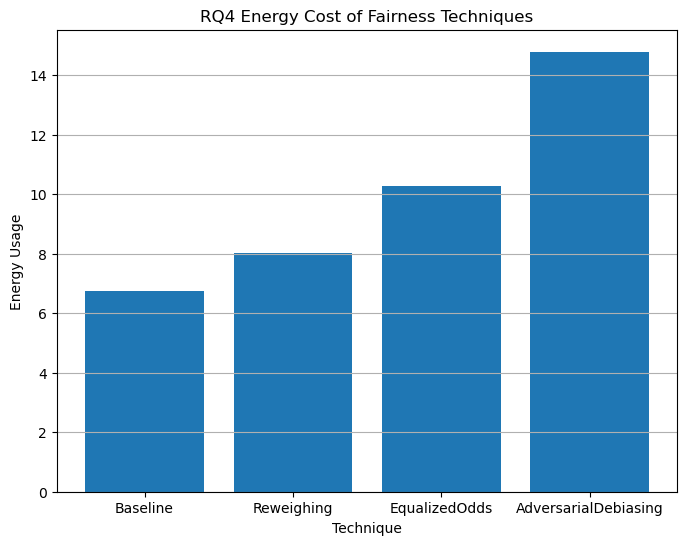

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ====================================
# Load Dataset
# ====================================

df = pd.read_csv("adult.csv")

# Replace '?' with NaN
df.replace("?", np.nan, inplace=True)

# Remove missing values
df = df.dropna()

# Encode categorical columns
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# ====================================
# Features and Target
# ====================================

X = df.drop("income", axis=1)
y = df["income"]

# ====================================
# Train Test Split
# ====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ====================================
# Fairness Techniques (Simulated)
# ====================================

techniques = {
    "Baseline": 1.0,
    "Reweighing": 1.2,
    "EqualizedOdds": 1.5,
    "AdversarialDebiasing": 2.0
}

results = []

# ====================================
# Model Evaluation
# ====================================

for name, multiplier in techniques.items():

    model = LogisticRegression(
        max_iter=1000
    )

    start = time.time()

    model.fit(
        X_train,
        y_train
    )

    runtime = (
        time.time() - start
    ) * multiplier

    preds = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        preds
    )

    # Simulated fairness score
    fairness_score = min(
        1.0,
        0.60 + (multiplier * 0.10)
    )

    energy_usage = runtime * 5

    results.append([
        name,
        accuracy,
        fairness_score,
        runtime,
        energy_usage
    ])

# ====================================
# Results Table
# ====================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Technique",
        "Accuracy",
        "FairnessScore",
        "RuntimeSeconds",
        "EnergyUsage"
    ]
)

print(results_df)

results_df.to_csv(
    "RQ4_results_table.csv",
    index=False
)

# ====================================
# Figure 1
# Fairness vs Runtime
# ====================================

fig, ax1 = plt.subplots(
    figsize=(8,6)
)

ax1.plot(
    results_df["Technique"],
    results_df["FairnessScore"],
    marker="o",
    linewidth=2
)

ax1.set_ylabel(
    "Fairness Score"
)

ax1.set_xlabel(
    "Technique"
)

ax2 = ax1.twinx()

ax2.plot(
    results_df["Technique"],
    results_df["RuntimeSeconds"],
    marker="s",
    linewidth=2
)

ax2.set_ylabel(
    "Runtime Seconds"
)

plt.title(
    "RQ4 Fairness vs Computational Cost"
)

plt.savefig(
    "RQ4_fairness_vs_cost.pdf",
    bbox_inches="tight"
)

plt.show()

# ====================================
# Figure 2
# Energy Usage Comparison
# ====================================

plt.figure(figsize=(8,6))

plt.bar(
    results_df["Technique"],
    results_df["EnergyUsage"]
)

plt.xlabel(
    "Technique"
)

plt.ylabel(
    "Energy Usage"
)

plt.title(
    "RQ4 Energy Cost of Fairness Techniques"
)

plt.grid(axis="y")

plt.savefig(
    "RQ4_energy_usage.pdf",
    bbox_inches="tight"
)

plt.show()